In [14]:
# ── Block 1: Imports and Load ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fg = pd.read_csv('fear_greed_index.csv')
tr = pd.read_csv('historical_data.csv')

print("Fear/Greed shape:", fg.shape)
print("Trades shape:", tr.shape)

Fear/Greed shape: (2644, 4)
Trades shape: (211224, 16)


In [15]:
# ── Block 2: Clean individual datasets before merging ────────────────────────
# --- Trades cleaning ---
tr['date'] = pd.to_datetime(
    tr['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date.astype(str)

tr = tr.drop(columns=[
    'Transaction Hash', 'Order ID', 'Trade ID',
    'Timestamp', 'Timestamp IST', 'Side', 'Size Tokens'])

tr = tr.drop_duplicates()

# --- Fear/Greed cleaning ---
fg['date'] = pd.to_datetime(fg['date']).dt.date.astype(str)
fg = fg.drop(columns=['timestamp'])

print("Trades cleaned shape:", tr.shape)
print("Fear/Greed cleaned shape:", fg.shape)

Trades cleaned shape: (211224, 10)
Fear/Greed cleaned shape: (2644, 3)


In [16]:
# ── Block 3: Merge datasets on date ──────────────────────────────────────────
merged = tr.merge(fg[['date', 'value', 'classification']],
                  on='date', how='inner')

print("Merged shape:", merged.shape)
print("Columns:", merged.columns.tolist())
print("\nSample row:")
print(merged.head(2).T)

Merged shape: (211218, 12)
Columns: ['Account', 'Coin', 'Execution Price', 'Size USD', 'Start Position', 'Direction', 'Closed PnL', 'Crossed', 'Fee', 'date', 'value', 'classification']

Sample row:
                                                          0  \
Account          0xae5eacaf9c6b9111fd53034a602c192a04e082ed   
Coin                                                   @107   
Execution Price                                      7.9769   
Size USD                                            7872.16   
Start Position                                          0.0   
Direction                                               Buy   
Closed PnL                                              0.0   
Crossed                                                True   
Fee                                                0.345404   
date                                             2024-12-02   
value                                                    80   
classification                                

In [17]:
# ── Block 4: Merged data sanity check ────────────────────────────────────────
print("Null values after merge:")
print(merged.isnull().sum())

print("\nDate range:", merged['date'].min(), "to", merged['date'].max())
print("Unique sentiment labels:", merged['classification'].unique())
print("Rows lost in merge:", len(tr) - len(merged),
      "(trades with no matching FG date)")

Null values after merge:
Account            0
Coin               0
Execution Price    0
Size USD           0
Start Position     0
Direction          0
Closed PnL         0
Crossed            0
Fee                0
date               0
value              0
classification     0
dtype: int64

Date range: 2023-05-01 to 2025-05-01
Unique sentiment labels: <StringArray>
['Extreme Greed', 'Extreme Fear', 'Fear', 'Greed', 'Neutral']
Length: 5, dtype: str
Rows lost in merge: 6 (trades with no matching FG date)


In [18]:
# ── Block 5: Separate closed trades for PnL analysis ─────────────────────────
# Closed PnL = 0 means the position was opened but not yet closed
# Only non-zero rows have actual realised profit or loss
closed = merged[merged['Closed PnL'] != 0].copy()
closed['win'] = (closed['Closed PnL'] > 0).astype(int)
closed['net_pnl'] = closed['Closed PnL'] - closed['Fee']

print("Total merged rows     :", len(merged))
print("Open trade rows (PnL=0):", (merged['Closed PnL'] == 0).sum())
print("Closed trade rows      :", len(closed))
print("\nWe will use 'closed' dataframe for all PnL analysis going forward")

Total merged rows     : 211218
Open trade rows (PnL=0): 106816
Closed trade rows      : 104402

We will use 'closed' dataframe for all PnL analysis going forward


In [20]:
# ── Block 6: Sentiment order and colour palette ───────────────────────────────
# Used consistently across all charts
cat_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
palette   = {
    'Extreme Fear':  '#d62728',
    'Fear':          '#ff7f0e',
    'Neutral':       '#7f7f7f',
    'Greed':         '#2ca02c',
    'Extreme Greed': '#1a7a1a'
}
colors = [palette[c] for c in cat_order]
print("Palette set. cat_order:", cat_order)

Palette set. cat_order: ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']


Trade count by sentiment:
                Count  Percentage
classification                   
Extreme Fear    21400       10.13
Fear            61837       29.28
Neutral         37686       17.84
Greed           50303       23.82
Extreme Greed   39992       18.93


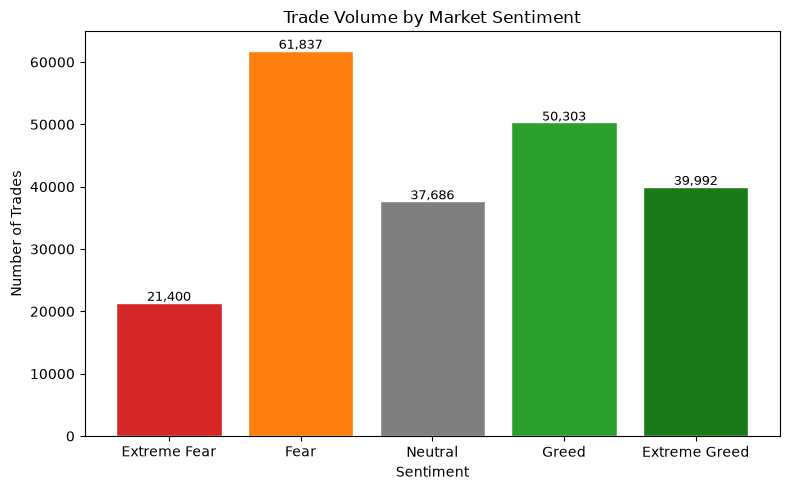

In [21]:
# ── Block 7: Analysis 1 — Trade volume by sentiment ──────────────────────────
trade_counts = merged.groupby('classification').size().reindex(cat_order)

print("Trade count by sentiment:")
pct = (trade_counts / trade_counts.sum() * 100).round(2)
print(pd.DataFrame({'Count': trade_counts, 'Percentage': pct}))

plt.figure(figsize=(8, 5))
bars = plt.bar(cat_order, trade_counts.values, color=colors, edgecolor='white')
for bar, v in zip(bars, trade_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300, f'{v:,}',
             ha='center', fontsize=9)
plt.title('Trade Volume by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.tight_layout()
plt.show()

Avg PnL per closed trade:
classification
Extreme Fear      71.03
Fear             112.63
Neutral           71.20
Greed             85.40
Extreme Greed    130.21
Name: Closed PnL, dtype: float64


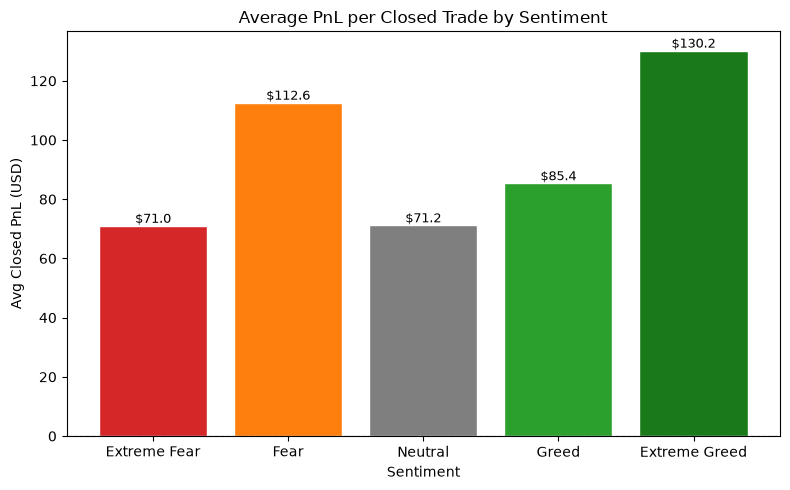

In [22]:
# ── Block 8: Analysis 2 — Average PnL per closed trade by sentiment ───────────
avg_pnl = closed.groupby('classification')['Closed PnL'].mean().reindex(cat_order)

print("Avg PnL per closed trade:")
print(avg_pnl.round(2))

plt.figure(figsize=(8, 5))
bar_colors = ['#d62728' if v < 0 else c
              for v, c in zip(avg_pnl.values, colors)]
bars = plt.bar(cat_order, avg_pnl.values, color=bar_colors, edgecolor='white')
for bar, v in zip(bars, avg_pnl.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             v + 1, f'${v:.1f}',
             ha='center', fontsize=9)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Average PnL per Closed Trade by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg Closed PnL (USD)')
plt.tight_layout()
plt.show()

Win rate by sentiment (%):
classification
Extreme Fear     76.22
Fear             87.29
Neutral          82.39
Greed            76.89
Extreme Greed    89.17
Name: win, dtype: float64


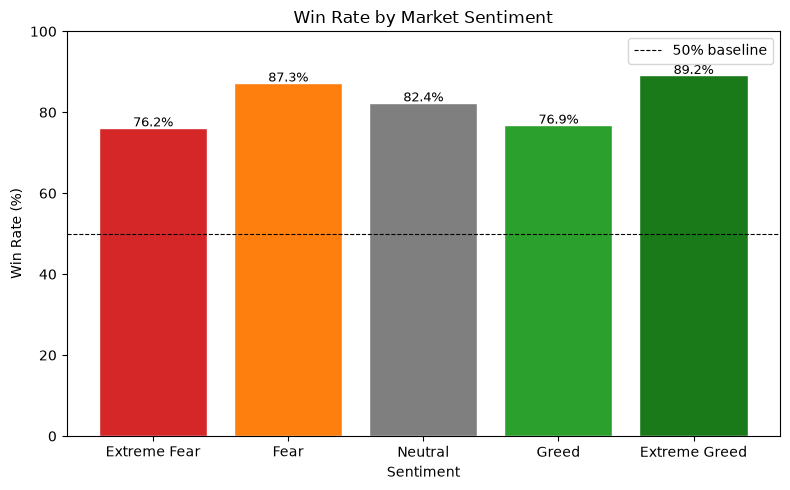

In [23]:
# ── Block 9: Analysis 3 — Win rate by sentiment ───────────────────────────────
win_rate = (closed.groupby('classification')['win']
            .mean().reindex(cat_order) * 100)

print("Win rate by sentiment (%):")
print(win_rate.round(2))

plt.figure(figsize=(8, 5))
bars = plt.bar(cat_order, win_rate.values, color=colors, edgecolor='white')
for bar, v in zip(bars, win_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             v + 0.3, f'{v:.1f}%',
             ha='center', fontsize=9)
plt.axhline(50, color='black', linewidth=0.8,
            linestyle='--', label='50% baseline')
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Total PnL by sentiment:
classification
Extreme Fear     0.739M
Fear             3.357M
Neutral          1.293M
Greed             2.15M
Extreme Greed    2.715M
Name: Closed PnL, dtype: str


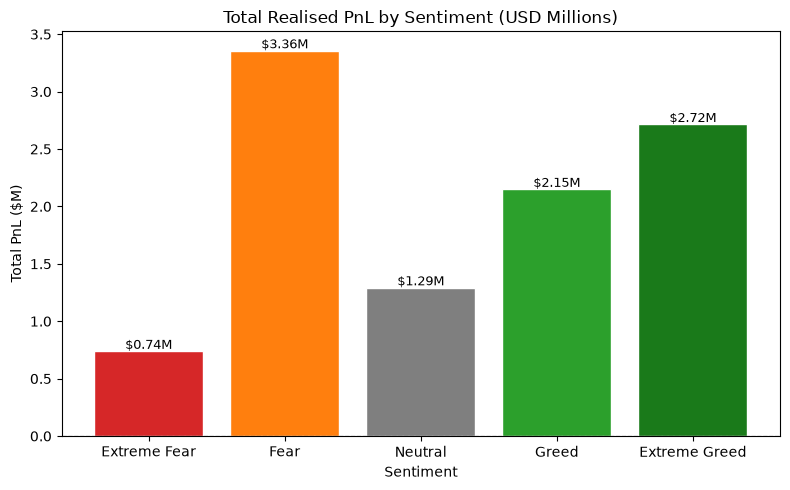

In [24]:
# ── Block 10: Analysis 4 — Total realised PnL by sentiment ───────────────────
total_pnl = closed.groupby('classification')['Closed PnL'].sum().reindex(cat_order)

print("Total PnL by sentiment:")
print((total_pnl / 1e6).round(3).astype(str) + "M")

plt.figure(figsize=(8, 5))
bar_colors = ['#d62728' if v < 0 else c
              for v, c in zip(total_pnl.values, colors)]
bars = plt.bar(cat_order, total_pnl.values / 1e6,
               color=bar_colors, edgecolor='white')
for bar, v in zip(bars, total_pnl.values / 1e6):
    plt.text(bar.get_x() + bar.get_width()/2,
             v + 0.02, f'${v:.2f}M',
             ha='center', fontsize=9)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Total Realised PnL by Sentiment (USD Millions)')
plt.xlabel('Sentiment')
plt.ylabel('Total PnL ($M)')
plt.tight_layout()
plt.show()

Avg trade size (USD) by sentiment:
classification
Extreme Fear     5349.73
Fear             7816.11
Neutral          4782.73
Greed            5736.88
Extreme Greed    3112.25
Name: Size USD, dtype: float64


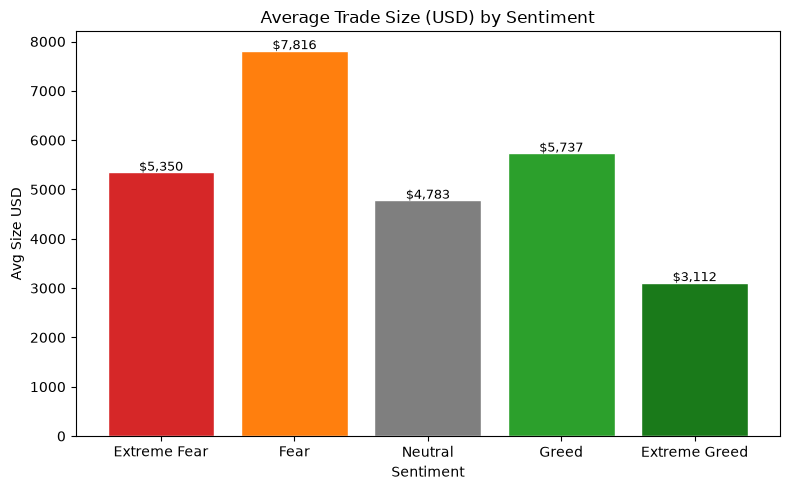

In [25]:
# ── Block 11: Analysis 5 — Average trade size by sentiment ───────────────────
avg_size = merged.groupby('classification')['Size USD'].mean().reindex(cat_order)

print("Avg trade size (USD) by sentiment:")
print(avg_size.round(2))

plt.figure(figsize=(8, 5))
bars = plt.bar(cat_order, avg_size.values, color=colors, edgecolor='white')
for bar, v in zip(bars, avg_size.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             v + 30, f'${v:,.0f}',
             ha='center', fontsize=9)
plt.title('Average Trade Size (USD) by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg Size USD')
plt.tight_layout()
plt.show()

Long % vs Short % by sentiment:
dir_simple      long_pct  short_pct
classification                     
Extreme Fear       65.71      34.29
Fear               62.00      38.00
Neutral            61.36      38.64
Greed              42.29      57.71
Extreme Greed      46.61      53.39


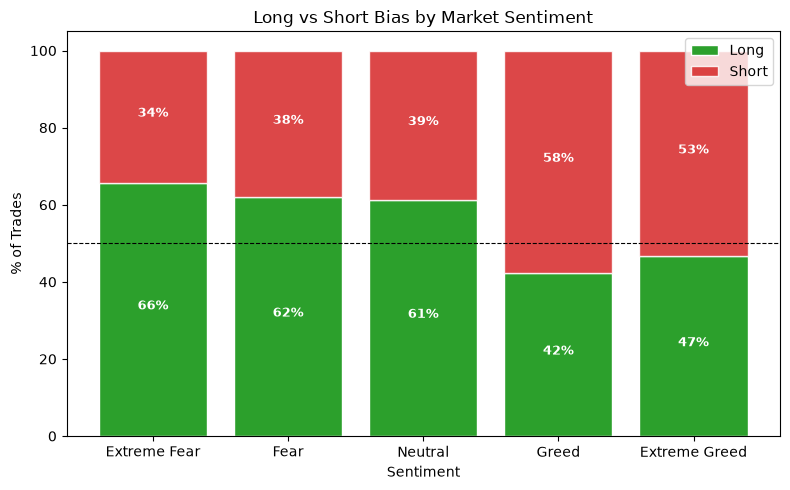

In [26]:
# ── Block 12: Analysis 6 — Long vs Short bias by sentiment ───────────────────
direction_map = {
    'Open Long':  'Long', 'Close Long':  'Long',
    'Open Short': 'Short','Close Short': 'Short',
    'Buy': 'Long', 'Sell': 'Short'
}
merged['dir_simple'] = merged['Direction'].map(direction_map)
ls = merged[merged['dir_simple'].isin(['Long', 'Short'])]

ls_ratio = (ls.groupby(['classification', 'dir_simple'])
            .size().unstack(fill_value=0).reindex(cat_order))
ls_ratio['long_pct']  = (ls_ratio['Long'] /
                         (ls_ratio['Long'] + ls_ratio['Short']) * 100)
ls_ratio['short_pct'] = 100 - ls_ratio['long_pct']

print("Long % vs Short % by sentiment:")
print(ls_ratio[['long_pct', 'short_pct']].round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cat_order, ls_ratio['long_pct'],
       label='Long', color='#2ca02c', edgecolor='white')
ax.bar(cat_order, ls_ratio['short_pct'],
       bottom=ls_ratio['long_pct'],
       label='Short', color='#d62728', edgecolor='white', alpha=0.85)
for i, (l, s) in enumerate(zip(ls_ratio['long_pct'],
                                ls_ratio['short_pct'])):
    ax.text(i, l / 2,      f'{l:.0f}%',
            ha='center', color='white', fontsize=9, fontweight='bold')
    ax.text(i, l + s / 2,  f'{s:.0f}%',
            ha='center', color='white', fontsize=9, fontweight='bold')
ax.axhline(50, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Long vs Short Bias by Market Sentiment')
ax.set_xlabel('Sentiment')
ax.set_ylabel('% of Trades')
ax.legend()
plt.tight_layout()
plt.show()

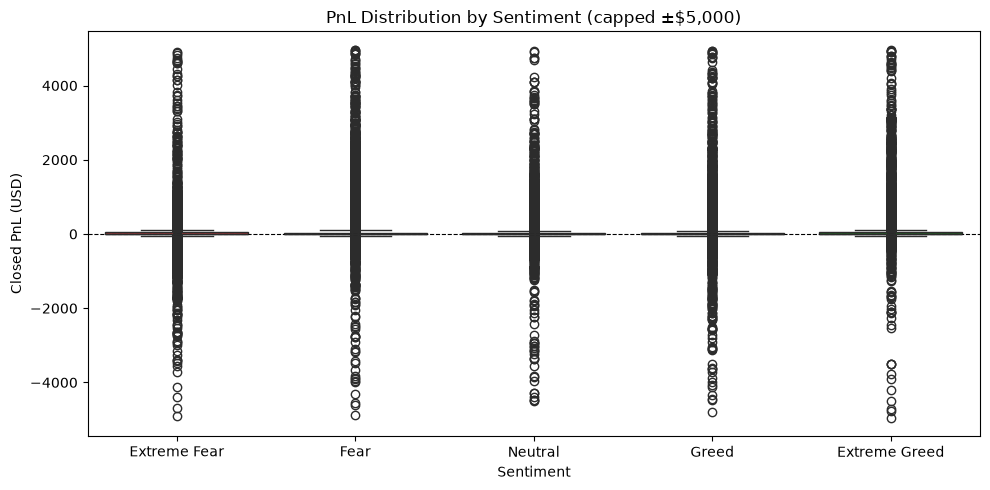

In [27]:
# ── Block 13: Analysis 7 — PnL distribution boxplot by sentiment ─────────────
# Cap at ±5000 for readability (extreme outliers compress the chart)
pnl_cap = closed[closed['Closed PnL'].between(-5000, 5000)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=pnl_cap, x='classification', y='Closed PnL',
            order=cat_order, palette=palette)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('PnL Distribution by Sentiment (capped ±$5,000)')
plt.xlabel('Sentiment')
plt.ylabel('Closed PnL (USD)')
plt.tight_layout()
plt.show()

Gross vs Net avg PnL by sentiment:
                Gross PnL  Net PnL (after fee)  Fee Impact
classification                                            
Extreme Fear        71.03                69.85        1.18
Fear               112.63               111.05        1.58
Neutral             71.20                69.97        1.23
Greed               85.40                84.23        1.18
Extreme Greed      130.21               129.55        0.66


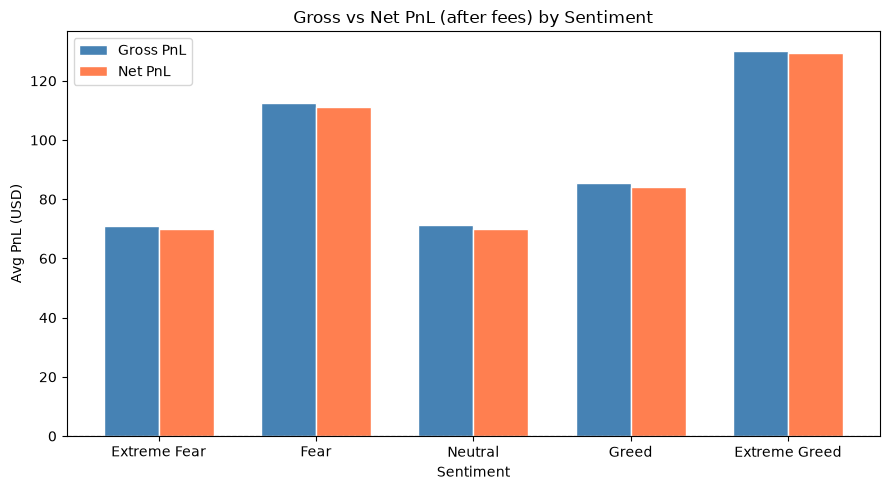

In [28]:
# ── Block 14: Analysis 8 — Net PnL after fees by sentiment ───────────────────
net_pnl = closed.groupby('classification')['net_pnl'].mean().reindex(cat_order)
gross    = closed.groupby('classification')['Closed PnL'].mean().reindex(cat_order)

print("Gross vs Net avg PnL by sentiment:")
comparison = pd.DataFrame({
    'Gross PnL': gross.round(2),
    'Net PnL (after fee)': net_pnl.round(2),
    'Fee Impact': (gross - net_pnl).round(2)
})
print(comparison)

x = range(len(cat_order))
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar([i - width/2 for i in x], gross.values,
        width=width, label='Gross PnL', color='steelblue', edgecolor='white')
plt.bar([i + width/2 for i in x], net_pnl.values,
        width=width, label='Net PnL', color='coral', edgecolor='white')
plt.xticks(list(x), cat_order)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Gross vs Net PnL (after fees) by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg PnL (USD)')
plt.legend()
plt.tight_layout()
plt.show()

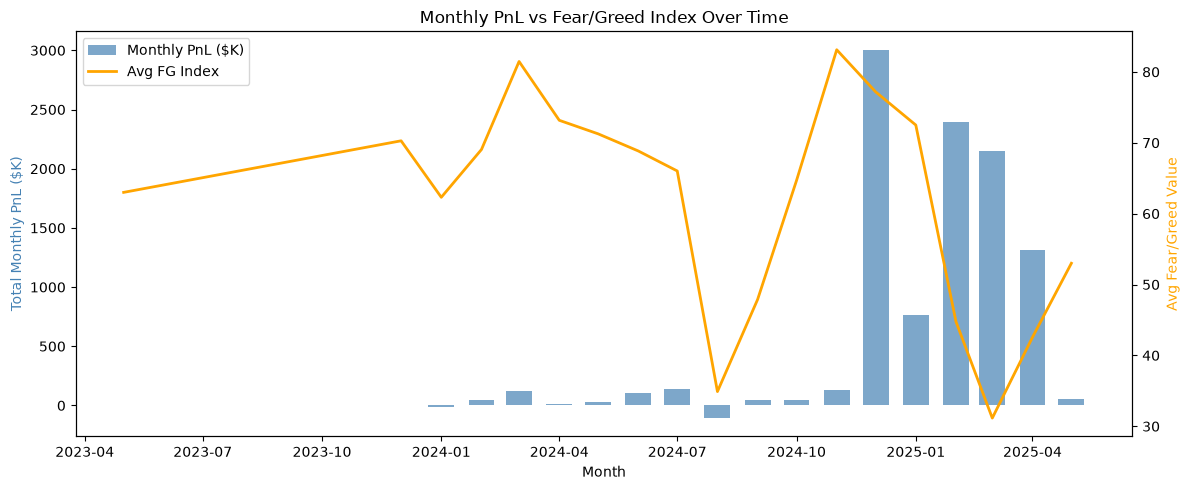

In [29]:
# ── Block 15: Analysis 9 — Monthly PnL trend vs FG index ─────────────────────
closed['month'] = pd.to_datetime(closed['date']).dt.to_period('M')
monthly_pnl = (closed.groupby('month')['Closed PnL']
               .sum().reset_index())
monthly_pnl['month_dt'] = monthly_pnl['month'].dt.to_timestamp()

fg_monthly = (merged.groupby(
    pd.to_datetime(merged['date']).dt.to_period('M'))['value']
    .mean().reset_index())
fg_monthly['month_dt'] = fg_monthly['date'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_pnl['month_dt'],
        monthly_pnl['Closed PnL'] / 1e3,
        color='steelblue', alpha=0.7, width=20, label='Monthly PnL ($K)')
ax2.plot(fg_monthly['month_dt'], fg_monthly['value'],
         color='orange', linewidth=2, label='Avg FG Index')

ax1.set_ylabel('Total Monthly PnL ($K)', color='steelblue')
ax2.set_ylabel('Avg Fear/Greed Value', color='orange')
ax1.set_xlabel('Month')
plt.title('Monthly PnL vs Fear/Greed Index Over Time')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

Top 10 traders by total PnL:
Account_short   Closed PnL
0xb1231a4a... 2.143383e+06
0x083384f8... 1.600230e+06
0xbaaaf657... 9.401638e+05
0x513b8629... 8.404226e+05
0xbee1707d... 8.360806e+05
0x4acb90e7... 6.777471e+05
0x72743ae2... 4.293556e+05
0x430f0984... 4.165419e+05
0x75f7eeb8... 3.790954e+05
0x72c6a462... 3.605395e+05


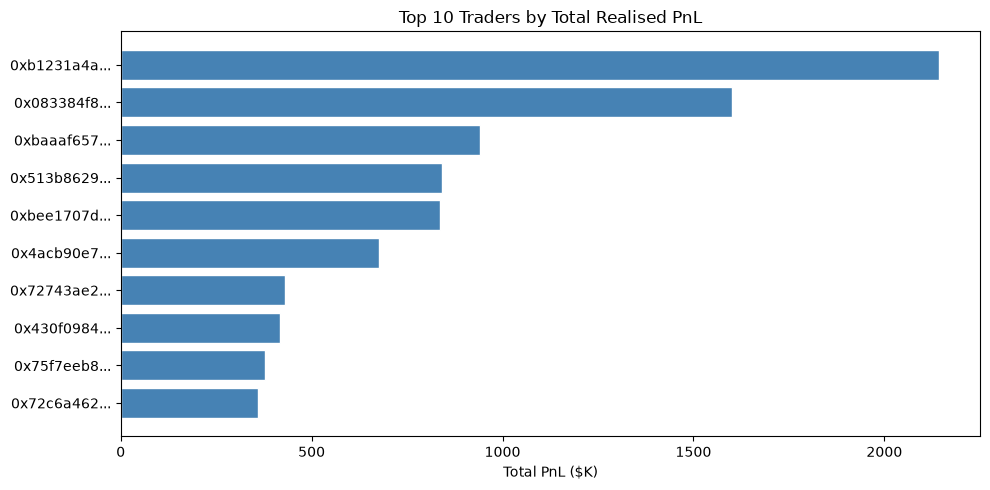

In [30]:
# ── Block 16: Analysis 10 — Top 10 traders overall PnL ───────────────────────
top10 = (closed.groupby('Account')['Closed PnL']
         .sum().nlargest(10).reset_index())
top10['Account_short'] = top10['Account'].str[:10] + '...'

print("Top 10 traders by total PnL:")
print(top10[['Account_short', 'Closed PnL']].to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(top10['Account_short'][::-1],
         top10['Closed PnL'][::-1] / 1e3,
         color='steelblue', edgecolor='white')
plt.xlabel('Total PnL ($K)')
plt.title('Top 10 Traders by Total Realised PnL')
plt.tight_layout()
plt.show()

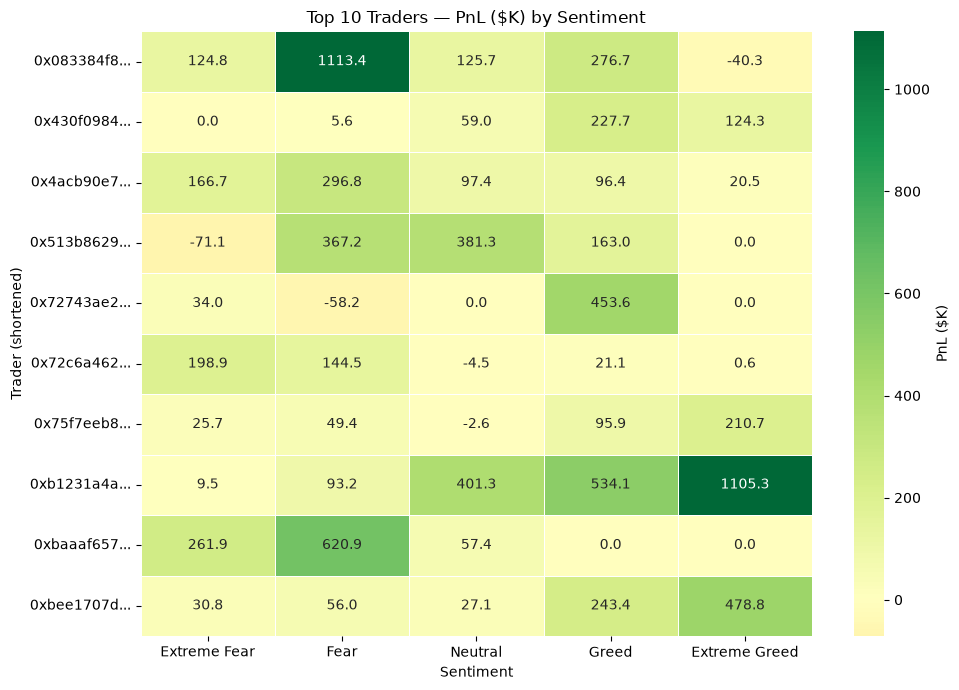

In [31]:
# ── Block 17: Analysis 11 — Top traders PnL heatmap by sentiment ─────────────
top10_accounts = (closed.groupby('Account')['Closed PnL']
                  .sum().nlargest(10).index)

trader_sent = (closed[closed['Account'].isin(top10_accounts)]
               .groupby(['Account', 'classification'])['Closed PnL']
               .sum().unstack(fill_value=0).reindex(columns=cat_order))

trader_sent.index = [i[:10] + '...' for i in trader_sent.index]

plt.figure(figsize=(10, 7))
sns.heatmap(trader_sent / 1e3,
            annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'PnL ($K)'})
plt.title('Top 10 Traders — PnL ($K) by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Trader (shortened)')
plt.tight_layout()
plt.show()

Top 10 coins by total PnL:
   Coin   Closed PnL
   @107 2.783913e+06
   HYPE 1.948485e+06
    SOL 1.639556e+06
    ETH 1.319979e+06
    BTC 8.680447e+05
MELANIA 3.903511e+05
    ENA 2.173295e+05
    SUI 1.992688e+05
    ZRO 1.837778e+05
   DOGE 1.475432e+05


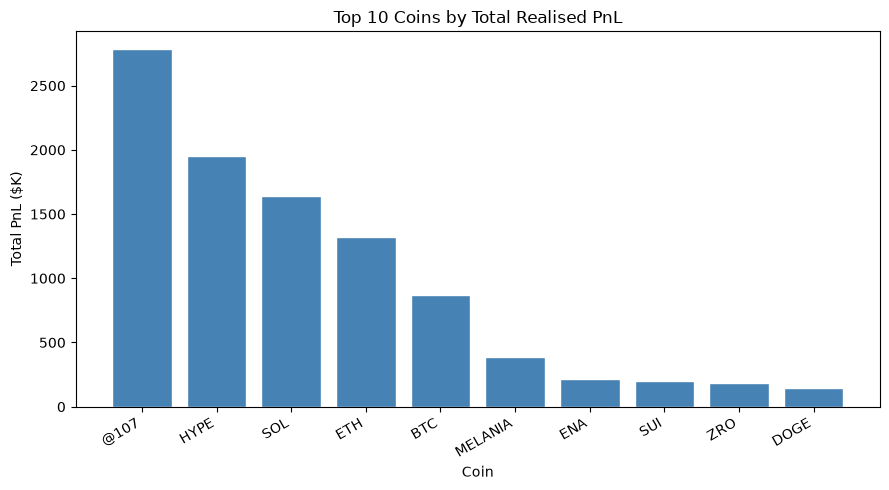

In [32]:
# ── Block 18: Analysis 12 — Top 10 coins by total PnL ────────────────────────
coin_pnl = (closed.groupby('Coin')['Closed PnL']
            .sum().nlargest(10).reset_index())

print("Top 10 coins by total PnL:")
print(coin_pnl.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.bar(coin_pnl['Coin'], coin_pnl['Closed PnL'] / 1e3,
        color='steelblue', edgecolor='white')
plt.title('Top 10 Coins by Total Realised PnL')
plt.xlabel('Coin')
plt.ylabel('Total PnL ($K)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ── Block 19: Final Conclusions ───────────────────────────────────────────────

=============================================================
   FINAL CONCLUSIONS — FEAR & GREED vs TRADER PERFORMANCE
=============================================================

DATASET SUMMARY
---------------
- Total merged rows       : 211,218 trades
- Rows used for PnL study : 104,402 (closed trades only)
- Open trade rows removed : 106,816 (Closed PnL = 0, no profit/loss yet)
- Date range              : May 2023 to May 2025
- Traders                 : 32 unique accounts
- Coins                   : 246 unique coins
- Only 6 rows lost during merge (trades with no matching FG date)

------------------------------------------------------------
1. TRADE VOLUME BY SENTIMENT
------------------------------------------------------------
- Fear days saw the highest trading activity (61,837 trades, 29.3%)
- Extreme Greed saw decent activity too (39,992 trades)
- Extreme Fear had the least trades (21,400) — fear reduces participation
- Traders are most active when market is fearful, not euphoric

------------------------------------------------------------
2. AVERAGE PnL PER TRADE
------------------------------------------------------------
- Extreme Greed : $130.21 per trade  (highest)
- Fear          : $112.63 per trade  (second highest)
- Neutral       : $71.20 per trade
- Extreme Fear  : $71.03 per trade   (lowest)
- Both extremes of sentiment produce better per-trade returns
  than the middle — flat/neutral markets are least rewarding

------------------------------------------------------------
3. WIN RATE BY SENTIMENT
------------------------------------------------------------
- Extreme Greed : 89.17%  (highest win rate)
- Fear          : 87.29%  (second highest)
- Neutral       : 82.39%
- Greed         : 76.89%
- Extreme Fear  : 76.22%  (lowest win rate)
- Traders close winning trades most often during Extreme Greed —
  they are selective and patient at market peaks

------------------------------------------------------------
4. TOTAL REALISED PnL
------------------------------------------------------------
- Fear          : $3.36M  (highest total profit)
- Extreme Greed : $2.71M
- Greed         : $2.15M
- Neutral       : $1.29M
- Extreme Fear  : $0.74M  (lowest total profit)
- Fear dominates total PnL because it combines high volume
  with solid per-trade returns

------------------------------------------------------------
5. AVERAGE TRADE SIZE
------------------------------------------------------------
- Fear          : $7,816  (largest avg position)
- Greed         : $5,737
- Extreme Fear  : $5,350
- Neutral       : $4,783
- Extreme Greed : $3,112  (smallest avg position)
- Traders put in the most money when market is fearful —
  they see it as a buying opportunity with more capital
- They reduce position size at Extreme Greed — cautious at peaks

------------------------------------------------------------
6. LONG VS SHORT BIAS
------------------------------------------------------------
- Extreme Fear : 65.7% Long  (traders heavily buying the dip)
- Fear         : 62.0% Long
- Neutral      : 61.4% Long
- Greed        : 42.3% Long  (starting to short the rally)
- Extreme Greed: 46.6% Long
- This is the clearest signal of contrarian behaviour —
  traders go long during fear and shift to short during greed

------------------------------------------------------------
7. FEES vs NET PnL
------------------------------------------------------------
- Average fee is only $1-2 per trade across all sentiments
- Net PnL after fees barely differs from gross PnL
- Fees are not a meaningful drag on performance here

------------------------------------------------------------
8. TOP TRADERS
------------------------------------------------------------
- Top trader made $2.14M total profit over 2 years
- 2nd place: $1.60M  |  3rd place: $0.94M
- Most top traders earned the bulk of their profits during
  Fear periods — confirmed by the heatmap
- A few traders show losses in Extreme Fear — not everyone
  executes the contrarian strategy successfully

------------------------------------------------------------
9. TOP COINS BY PnL
------------------------------------------------------------
- HYPE, BTC and ETH are the top profit-generating coins
- HYPE alone accounts for 32% of all trades in the dataset
- Most altcoins have minimal PnL contribution

------------------------------------------------------------
OVERALL KEY INSIGHT
------------------------------------------------------------
Hyperliquid traders collectively follow a contrarian strategy:

  >> Buy more (larger positions, more longs) during Fear
  >> Reduce size and shift to shorts during Greed
  >> Best win rates and per-trade PnL happen at extremes
  >> Fear days generate the most total profit due to volume

The data strongly supports the classic market wisdom:
"Be greedy when others are fearful,
 be fearful when others are greedy."
=============================================================
""")